In [26]:
import numpy as np
import matplotlib.pyplot as plt

from _architecture import BaseModel

In [27]:
X = np.arange(0,22,1)
Y_true = (X>11.5).astype(np.int8)

# data
np.c_[X,Y_true]


array([[ 0,  0],
       [ 1,  0],
       [ 2,  0],
       [ 3,  0],
       [ 4,  0],
       [ 5,  0],
       [ 6,  0],
       [ 7,  0],
       [ 8,  0],
       [ 9,  0],
       [10,  0],
       [11,  0],
       [12,  1],
       [13,  1],
       [14,  1],
       [15,  1],
       [16,  1],
       [17,  1],
       [18,  1],
       [19,  1],
       [20,  1],
       [21,  1]])

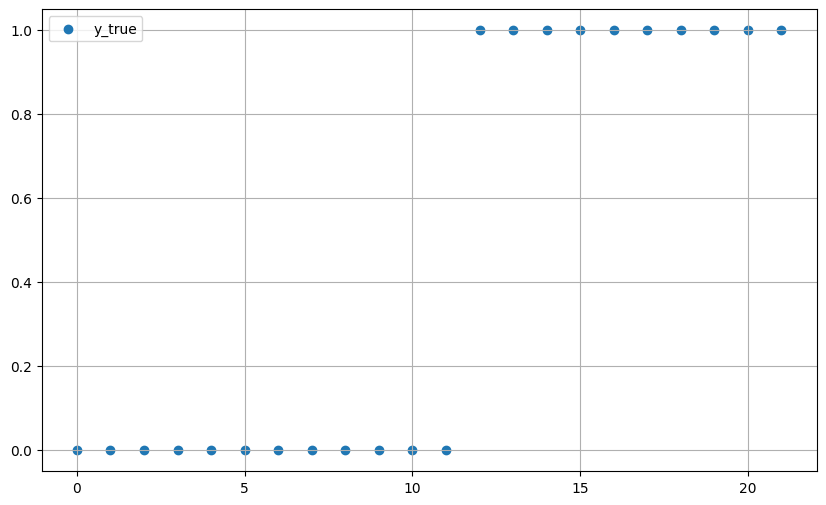

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y_true,label='y_true')
plt.legend()
plt.grid()
plt.show()

In [29]:
class BinaryLogisticRegression(BaseModel):

    def _sigmoid(self, z):
        
        return 1/ (1+ np.exp(-z))


    def fit(self,X, y ):

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for itr in range(self.max_iterations):

            logits = np.dot(X,self.weights) + self.bias
            sig_y = self._sigmoid(logits)

            dw = np.sum(np.dot(X.T, (sig_y - y)))/n_samples
            db = np.sum(sig_y - y)/n_samples

            self.weights -= self.lr*dw
            self.bias -=  self.lr*db



    def predict_proba(self, X ):

        return self._sigmoid(X@self.weights + self.bias)
    

    def predict(self,X):
        
        _probs = self.predict_proba(X)
        return [ 0 if i<0.5 else 1 for i in _probs]
    

    def score(self, y_true, y_pred):
        return
    
    def _compute_loss(y_true, y_pred):
        return

        


In [30]:
lr_classifier = BinaryLogisticRegression(max_iterations=10**4,lr=1e-3)

X_=  X.reshape(-1,1)
lr_classifier.fit(X_,Y_true)

y_probs_ = lr_classifier.predict_proba(X_)
y_probs_

array([0.17806694, 0.20607203, 0.23721043, 0.27144528, 0.30862194,
       0.348455  , 0.39052524, 0.43428915, 0.47910215, 0.52425402,
       0.56901284, 0.61267182, 0.65459283, 0.69424099, 0.73120686,
       0.76521502, 0.79612013, 0.82389338, 0.84860274, 0.87039055,
       0.88945132, 0.90601164])

In [31]:
y_pred_cls = lr_classifier.predict(X_)

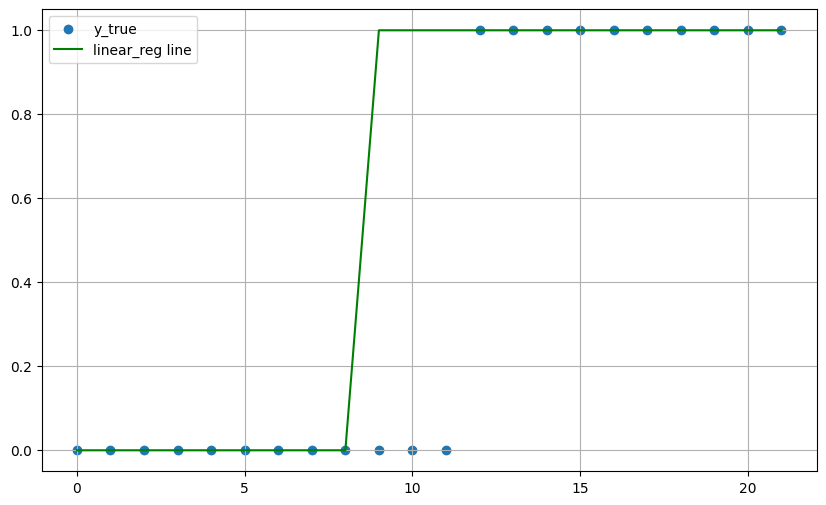

In [32]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y_true,label='y_true')
plt.plot(X,y_pred_cls,label='linear_reg line',color='green')
plt.legend()
plt.grid()
plt.show()